# Ground Truth Dataset Analysis

> **Note:** This ground truth is based on the **old version** of the DMP label schema.
> It was subsequently updated using a rule-based approach informed by suggestions from
> Becky (Product Manager) to better reflect the intended label structure.

Overview of the manually labeled DMP samples and comparison with model predictions.
**Dataset:** \data/input/ground_truth_old_version/\ · 10 samples · 5 label types

In [1]:
from dmpbridge.evaluation.evaluate import extract_gold, MANUAL_DIR, load_method, confusion_matrix_df
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import pandas as pd
from pathlib import Path

LABELS     = ['title', 'section.title', 'section.description', 'question.text', 'answer.text']
SHORT      = ['title', 'sec.title', 'sec.desc', 'q.text', 'ans.text']
COLORS     = ['#1e3a5f', '#2563eb', '#60a5fa', '#f59e0b', '#10b981']
label_color = dict(zip(LABELS, COLORS))

rows = []
for i in range(1, 11):
    p = MANUAL_DIR / f'sample{i}_old_dmp.json'
    if not p.exists(): continue
    gold = extract_gold(p)
    counts = {lbl: 0 for lbl in LABELS}
    for _, lbl in gold:
        counts[lbl] += 1
    rows.append({'sample': f'sample{i}', **counts, 'total': len(gold)})

df_gt = pd.DataFrame(rows)
print('=== Ground Truth Label Counts per Sample ===')
print(df_gt.to_string(index=False))
print()
print('=== Totals ===')
for lbl in LABELS:
    print(f'  {lbl:<25} : {df_gt[lbl].sum():>4}')
print(f'  {"TOTAL":<25} : {df_gt["total"].sum():>4}')

=== Ground Truth Label Counts per Sample ===
  sample  title  section.title  section.description  question.text  answer.text  total
 sample1      1              6                    0              9           12     28
 sample2      1              4                    4              7            9     25
 sample3      1              5                    4              0            4     14
 sample4      1              0                    0              0            1      2
 sample5      1              6                    0              0            6     13
 sample6      1              5                    0              0            5     11
 sample7      1              0                    0              0            1      2
 sample8      1              6                    0              0            6     13
 sample9      1              5                    0              0            5     11
sample10      1              6                    0              0            6     1

## Label Distribution per Sample — Old Version
Each bar shows the breakdown of label types in that sample's ground truth (original annotations).

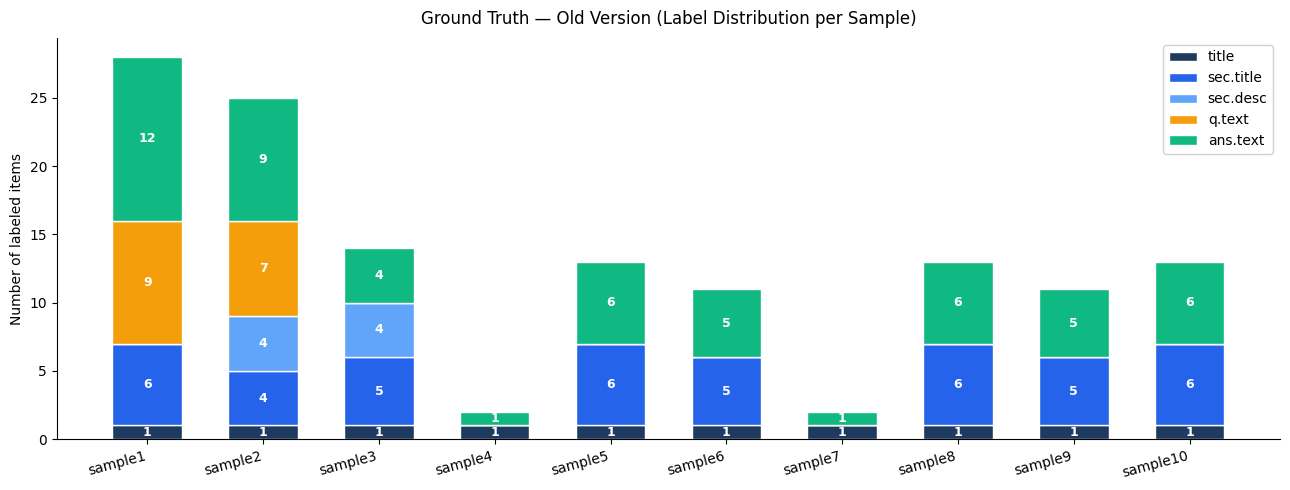

In [2]:
samples = df_gt['sample'].tolist()
x = range(len(samples))

fig, ax = plt.subplots(figsize=(13, 5))
bottom = [0] * len(samples)

for lbl, color, short in zip(LABELS, COLORS, SHORT):
    vals = df_gt[lbl].tolist()
    bars = ax.bar(x, vals, bottom=bottom, color=color, label=short, width=0.6, edgecolor='white')
    for bar, v, b in zip(bars, vals, bottom):
        if v > 0:
            ax.text(bar.get_x() + bar.get_width()/2, b + v/2,
                    str(v), ha='center', va='center', fontsize=9,
                    color='white', fontweight='bold')
    bottom = [b + v for b, v in zip(bottom, vals)]

ax.set_xticks(list(x))
ax.set_xticklabels(samples, rotation=15, ha='right')
ax.set_ylabel('Number of labeled items')
ax.set_title('Ground Truth — Old Version (Label Distribution per Sample)', pad=10)
ax.legend(loc='upper right', framealpha=0.9)
sns.despine()
plt.tight_layout()
plt.show()

## Label Distribution per Sample — New Version
Same chart for the new version (after Becky's rule-based updates).

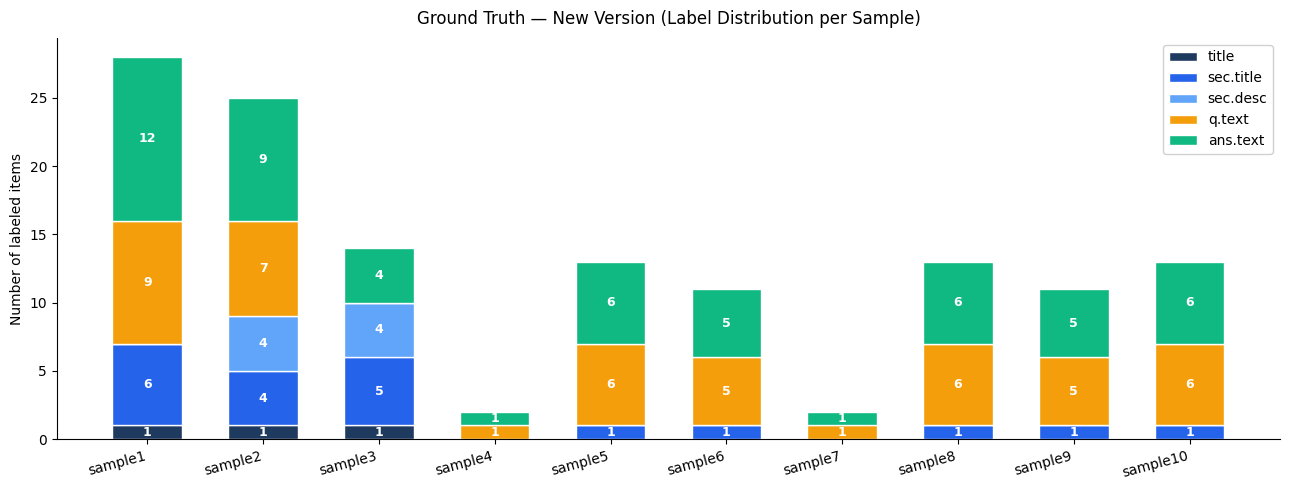

In [3]:
from dmpbridge.evaluation.evaluate import NEW_MANUAL_DIR

rows_new = []
for i in range(1, 11):
    p = NEW_MANUAL_DIR / f'sample{i}_new_dmp.json'
    if not p.exists(): continue
    gold = extract_gold(p)
    counts = {lbl: 0 for lbl in LABELS}
    for _, lbl in gold:
        counts[lbl] += 1
    rows_new.append({'sample': f'sample{i}', **counts, 'total': len(gold)})

df_new = pd.DataFrame(rows_new)
samples_new = df_new['sample'].tolist()
x = range(len(samples_new))

fig, ax = plt.subplots(figsize=(13, 5))
bottom = [0] * len(samples_new)

for lbl, color, short in zip(LABELS, COLORS, SHORT):
    vals = df_new[lbl].tolist()
    bars = ax.bar(x, vals, bottom=bottom, color=color, label=short, width=0.6, edgecolor='white')
    for bar, v, b in zip(bars, vals, bottom):
        if v > 0:
            ax.text(bar.get_x() + bar.get_width()/2, b + v/2,
                    str(v), ha='center', va='center', fontsize=9,
                    color='white', fontweight='bold')
    bottom = [b + v for b, v in zip(bottom, vals)]

ax.set_xticks(list(x))
ax.set_xticklabels(samples_new, rotation=15, ha='right')
ax.set_ylabel('Number of labeled items')
ax.set_title('Ground Truth — New Version (Label Distribution per Sample)', pad=10)
ax.legend(loc='upper right', framealpha=0.9)
sns.despine()
plt.tight_layout()
plt.show()